<a href="https://colab.research.google.com/github/Pushkarsinghs/indian_stock-analysis/blob/main/02_technical_analysisipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Indian Stock Market Analysis
## Notebook 2: Technical Analysis

This notebook loads the cleaned NIFTY 50 data from Google Drive and computes
all major technical indicators used by professional traders.

**Indicators covered:** RSI, MACD, Bollinger Bands, SMA, EMA, ATR, OBV, Stochastic
**Output:** Enriched dataset saved to Google Drive + Power BI ready CSV


In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install ta pyarrow -q

print("✅ Ready!")

Mounted at /content/drive
  Preparing metadata (setup.py) ... done
✅ Ready!


In [2]:
import pandas as pd
import numpy as np
import ta

BASE = '/content/drive/MyDrive/indian_stock_analysis'

# Load master data saved in Notebook 1
df = pd.read_parquet(f"{BASE}/data/processed/nifty50_master.parquet")
df["Date"] = pd.to_datetime(df["Date"])

print(f"✅ Data loaded successfully!")
print(f"📊 Shape: {df.shape}")
print(f"📅 Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"📈 Stocks: {df['Ticker'].nunique()}")
print(f"\nColumns: {list(df.columns)}")

✅ Data loaded successfully!
📊 Shape: (12249, 11)
📅 Date range: 2025-06-24 → 2026-06-24
📈 Stocks: 49

Columns: ['Date', 'Ticker', 'Sector', 'Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'Price_Change', 'Price_Change_Pct']


In [3]:
def add_technical_indicators(df):
    """Add all technical indicators for each stock individually"""

    results = []
    tickers = df["Ticker"].unique()

    print(f"⚙️  Computing indicators for {len(tickers)} stocks...\n")

    for i, ticker in enumerate(tickers, 1):
        stock = df[df["Ticker"] == ticker].copy().sort_values("Date")

        try:
            # ── Trend Indicators ──────────────────────────────
            # Simple & Exponential Moving Averages
            stock["SMA_20"]  = ta.trend.SMAIndicator(stock["Close"], window=20).sma_indicator()
            stock["SMA_50"]  = ta.trend.SMAIndicator(stock["Close"], window=50).sma_indicator()
            stock["SMA_200"] = ta.trend.SMAIndicator(stock["Close"], window=200).sma_indicator()
            stock["EMA_12"]  = ta.trend.EMAIndicator(stock["Close"], window=12).ema_indicator()
            stock["EMA_26"]  = ta.trend.EMAIndicator(stock["Close"], window=26).ema_indicator()

            # MACD
            macd = ta.trend.MACD(stock["Close"])
            stock["MACD"]        = macd.macd()
            stock["MACD_Signal"] = macd.macd_signal()
            stock["MACD_Hist"]   = macd.macd_diff()

            # ADX (trend strength)
            adx = ta.trend.ADXIndicator(stock["High"], stock["Low"], stock["Close"])
            stock["ADX"] = adx.adx()

            # ── Momentum Indicators ───────────────────────────
            # RSI
            stock["RSI"] = ta.momentum.RSIIndicator(stock["Close"], window=14).rsi()

            # Stochastic Oscillator
            stoch = ta.momentum.StochasticOscillator(stock["High"], stock["Low"], stock["Close"])
            stock["Stoch_K"] = stoch.stoch()
            stock["Stoch_D"] = stoch.stoch_signal()

            # Williams %R
            stock["Williams_R"] = ta.momentum.WilliamsRIndicator(
                stock["High"], stock["Low"], stock["Close"]
            ).williams_r()

            # ── Volatility Indicators ─────────────────────────
            # Bollinger Bands
            bb = ta.volatility.BollingerBands(stock["Close"], window=20, window_dev=2)
            stock["BB_Upper"]  = bb.bollinger_hband()
            stock["BB_Middle"] = bb.bollinger_mavg()
            stock["BB_Lower"]  = bb.bollinger_lband()
            stock["BB_Width"]  = bb.bollinger_wband()

            # ATR (Average True Range)
            stock["ATR"] = ta.volatility.AverageTrueRange(
                stock["High"], stock["Low"], stock["Close"]
            ).average_true_range()

            # ── Volume Indicators ─────────────────────────────
            # OBV (On Balance Volume)
            stock["OBV"] = ta.volume.OnBalanceVolumeIndicator(
                stock["Close"], stock["Volume"]
            ).on_balance_volume()

            # Volume SMA
            stock["Volume_SMA_20"] = stock["Volume"].rolling(window=20).mean()

            # ── Signal Generation ─────────────────────────────
            # Golden Cross / Death Cross
            stock["Golden_Cross"] = (
                (stock["SMA_50"] > stock["SMA_200"]) &
                (stock["SMA_50"].shift(1) <= stock["SMA_200"].shift(1))
            ).astype(int)

            stock["Death_Cross"] = (
                (stock["SMA_50"] < stock["SMA_200"]) &
                (stock["SMA_50"].shift(1) >= stock["SMA_200"].shift(1))
            ).astype(int)

            # RSI Signal
            stock["RSI_Signal"] = "Neutral"
            stock.loc[stock["RSI"] < 30, "RSI_Signal"] = "Oversold"
            stock.loc[stock["RSI"] > 70, "RSI_Signal"] = "Overbought"

            # MACD Signal
            stock["MACD_Crossover"] = (
                (stock["MACD"] > stock["MACD_Signal"]) &
                (stock["MACD"].shift(1) <= stock["MACD_Signal"].shift(1))
            ).astype(int)

            results.append(stock)
            print(f"  ✅ [{i:02d}/{len(tickers)}] {ticker}")

        except Exception as e:
            print(f"  ❌ [{i:02d}/{len(tickers)}] {ticker} — Error: {e}")

    final = pd.concat(results, ignore_index=True)
    print(f"\n✅ Done! Shape: {final.shape}")
    return final

tech_df = add_technical_indicators(df)

⚙️  Computing indicators for 49 stocks...

  ✅ [01/49] ADANIENT.NS
  ✅ [02/49] ADANIPORTS.NS
  ✅ [03/49] APOLLOHOSP.NS
  ✅ [04/49] ASIANPAINT.NS
  ✅ [05/49] AXISBANK.NS
  ✅ [06/49] BAJAJ-AUTO.NS
  ✅ [07/49] BAJAJFINSV.NS
  ✅ [08/49] BAJFINANCE.NS
  ✅ [09/49] BHARTIARTL.NS
  ✅ [10/49] BPCL.NS
  ✅ [11/49] BRITANNIA.NS
  ✅ [12/49] CIPLA.NS
  ✅ [13/49] COALINDIA.NS
  ✅ [14/49] DIVISLAB.NS
  ✅ [15/49] DRREDDY.NS
  ✅ [16/49] EICHERMOT.NS
  ✅ [17/49] GRASIM.NS
  ✅ [18/49] HCLTECH.NS
  ✅ [19/49] HDFCBANK.NS
  ✅ [20/49] HDFCLIFE.NS
  ✅ [21/49] HEROMOTOCO.NS
  ✅ [22/49] HINDALCO.NS
  ✅ [23/49] HINDUNILVR.NS
  ✅ [24/49] ICICIBANK.NS
  ✅ [25/49] INDUSINDBK.NS
  ✅ [26/49] INFY.NS
  ✅ [27/49] ITC.NS
  ✅ [28/49] JSWSTEEL.NS
  ✅ [29/49] KOTAKBANK.NS
  ✅ [30/49] LT.NS
  ✅ [31/49] LTF.NS
  ✅ [32/49] M&M.NS
  ✅ [33/49] MARUTI.NS
  ✅ [34/49] NESTLEIND.NS
  ✅ [35/49] NTPC.NS
  ✅ [36/49] ONGC.NS
  ✅ [37/49] POWERGRID.NS
  ✅ [38/49] RELIANCE.NS
  ✅ [39/49] SBILIFE.NS
  ✅ [40/49] SBIN.NS
  ✅ [41/49] SUNPHARMA

In [4]:
def generate_trading_signals(df):
    """
    Score each stock from -5 to +5 based on technical signals.
    Positive = Bullish, Negative = Bearish
    """
    df = df.copy()
    df["Signal_Score"] = 0

    # RSI signals
    df.loc[df["RSI"] < 30, "Signal_Score"] += 2   # Oversold = bullish
    df.loc[df["RSI"] > 70, "Signal_Score"] -= 2   # Overbought = bearish

    # MACD signals
    df.loc[df["MACD"] > df["MACD_Signal"], "Signal_Score"] += 1
    df.loc[df["MACD"] < df["MACD_Signal"], "Signal_Score"] -= 1

    # Price vs Moving Averages
    df.loc[df["Close"] > df["SMA_50"],  "Signal_Score"] += 1
    df.loc[df["Close"] < df["SMA_50"],  "Signal_Score"] -= 1
    df.loc[df["Close"] > df["SMA_200"], "Signal_Score"] += 1
    df.loc[df["Close"] < df["SMA_200"], "Signal_Score"] -= 1

    # Bollinger Band signals
    df.loc[df["Close"] < df["BB_Lower"], "Signal_Score"] += 1
    df.loc[df["Close"] > df["BB_Upper"], "Signal_Score"] -= 1

    # Overall signal label
    df["Signal"] = "Neutral"
    df.loc[df["Signal_Score"] >= 3,  "Signal"] = "Strong Buy"
    df.loc[df["Signal_Score"] == 2,  "Signal"] = "Buy"
    df.loc[df["Signal_Score"] == 1,  "Signal"] = "Weak Buy"
    df.loc[df["Signal_Score"] == -1, "Signal"] = "Weak Sell"
    df.loc[df["Signal_Score"] == -2, "Signal"] = "Sell"
    df.loc[df["Signal_Score"] <= -3, "Signal"] = "Strong Sell"

    print("✅ Trading signals generated!")

    # Show today's signals
    latest = df.groupby("Ticker").last().reset_index()
    summary = latest[["Ticker", "Sector", "Close", "RSI",
                       "Signal_Score", "Signal", "RSI_Signal"]].sort_values(
                       "Signal_Score", ascending=False)

    print("\n📊 Latest Signal Summary (Top 10 Bullish):")
    print(summary.head(10).to_string(index=False))

    return df

tech_df = generate_trading_signals(tech_df)

✅ Trading signals generated!

📊 Latest Signal Summary (Top 10 Bullish):
       Ticker         Sector   Close       RSI  Signal_Score     Signal RSI_Signal
BAJFINANCE.NS           NBFC  990.95 68.300337             3 Strong Buy    Neutral
  DIVISLAB.NS         Pharma 6753.50 54.944292             3 Strong Buy    Neutral
 EICHERMOT.NS           Auto 7572.00 61.500899             3 Strong Buy    Neutral
       LTF.NS           NBFC  296.55 62.020020             3 Strong Buy    Neutral
     TITAN.NS       Consumer 4323.80 55.604550             3 Strong Buy    Neutral
      SBIN.NS        Banking 1034.60 60.711269             3 Strong Buy    Neutral
        LT.NS Infrastructure 4181.70 62.963974             3 Strong Buy    Neutral
 ICICIBANK.NS        Banking 1373.60 68.958864             3 Strong Buy    Neutral
   DRREDDY.NS         Pharma 1328.40 64.841117             2        Buy    Neutral
 SUNPHARMA.NS         Pharma 1874.40 67.319703             2        Buy    Neutral


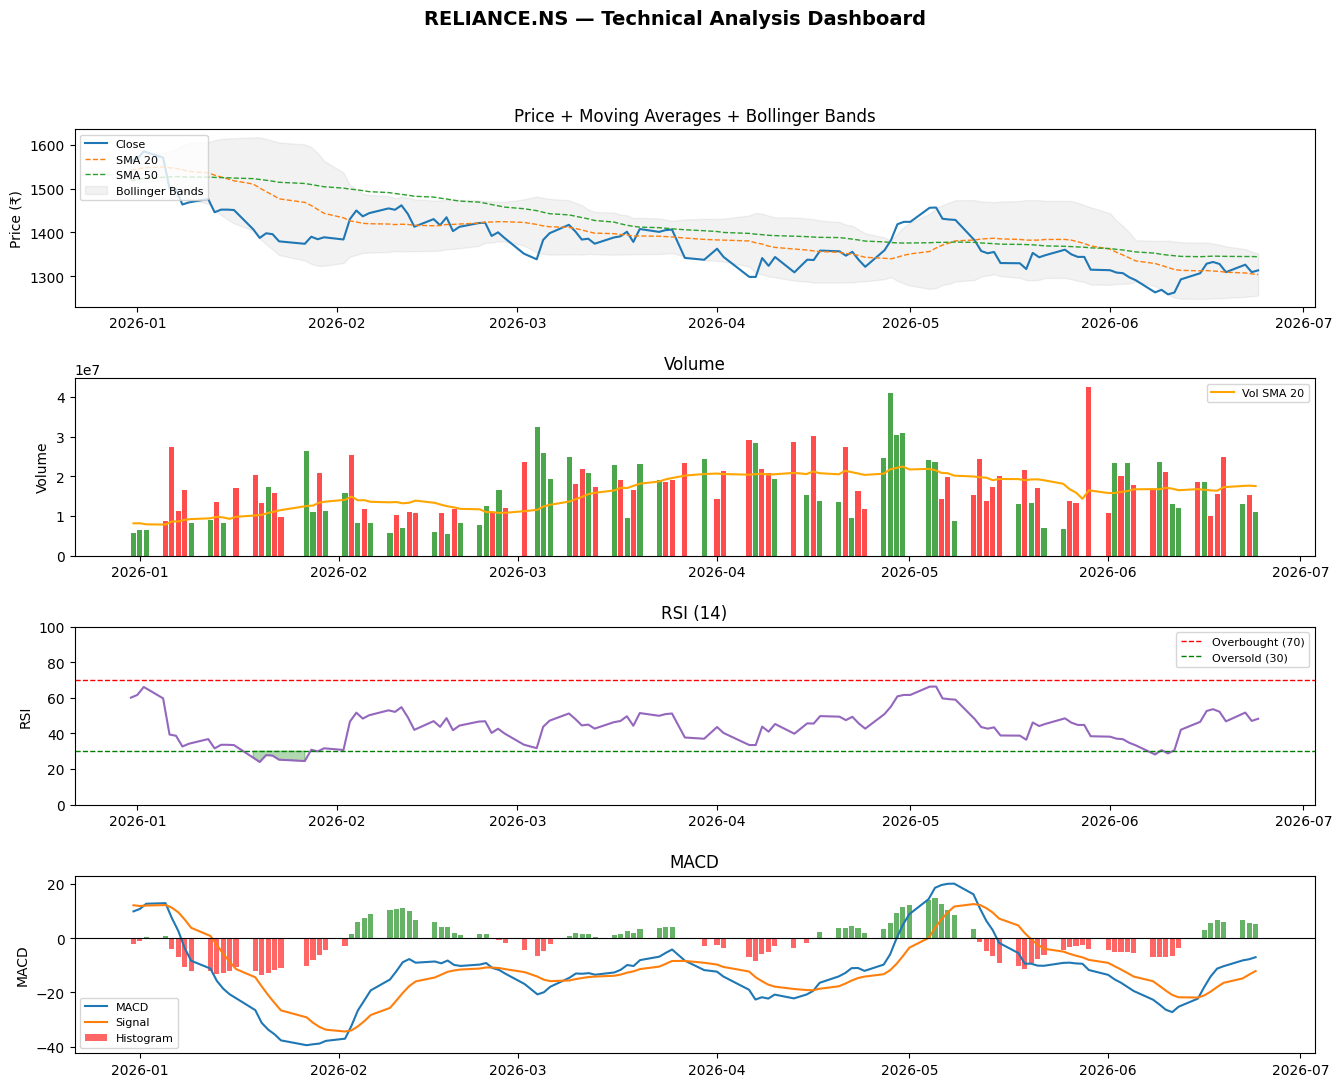

✅ Chart saved!


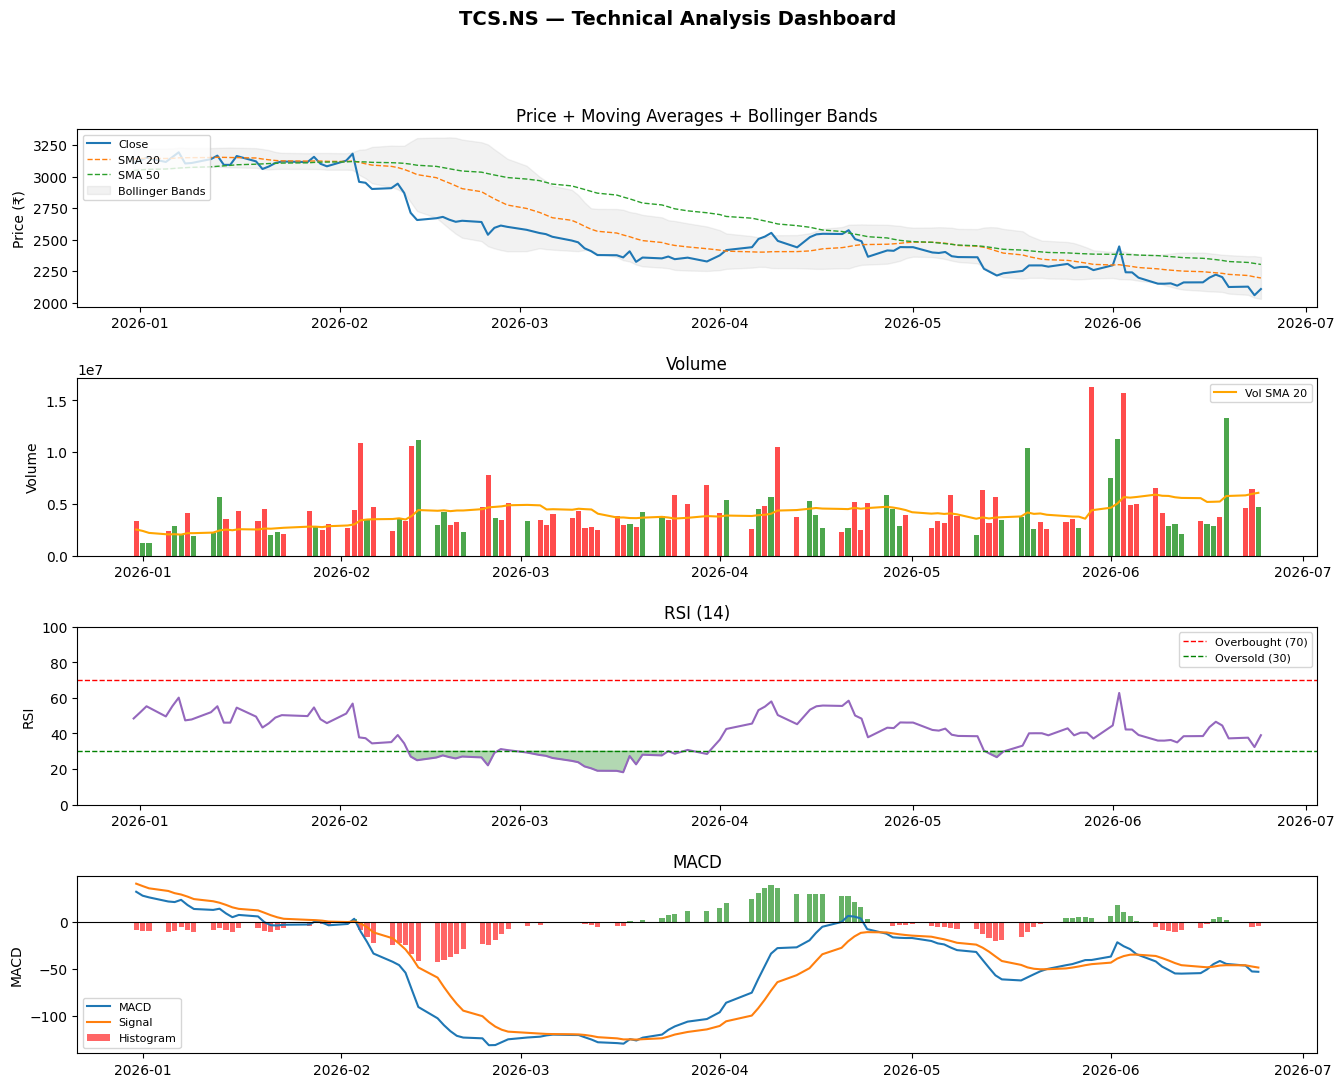

✅ Chart saved!


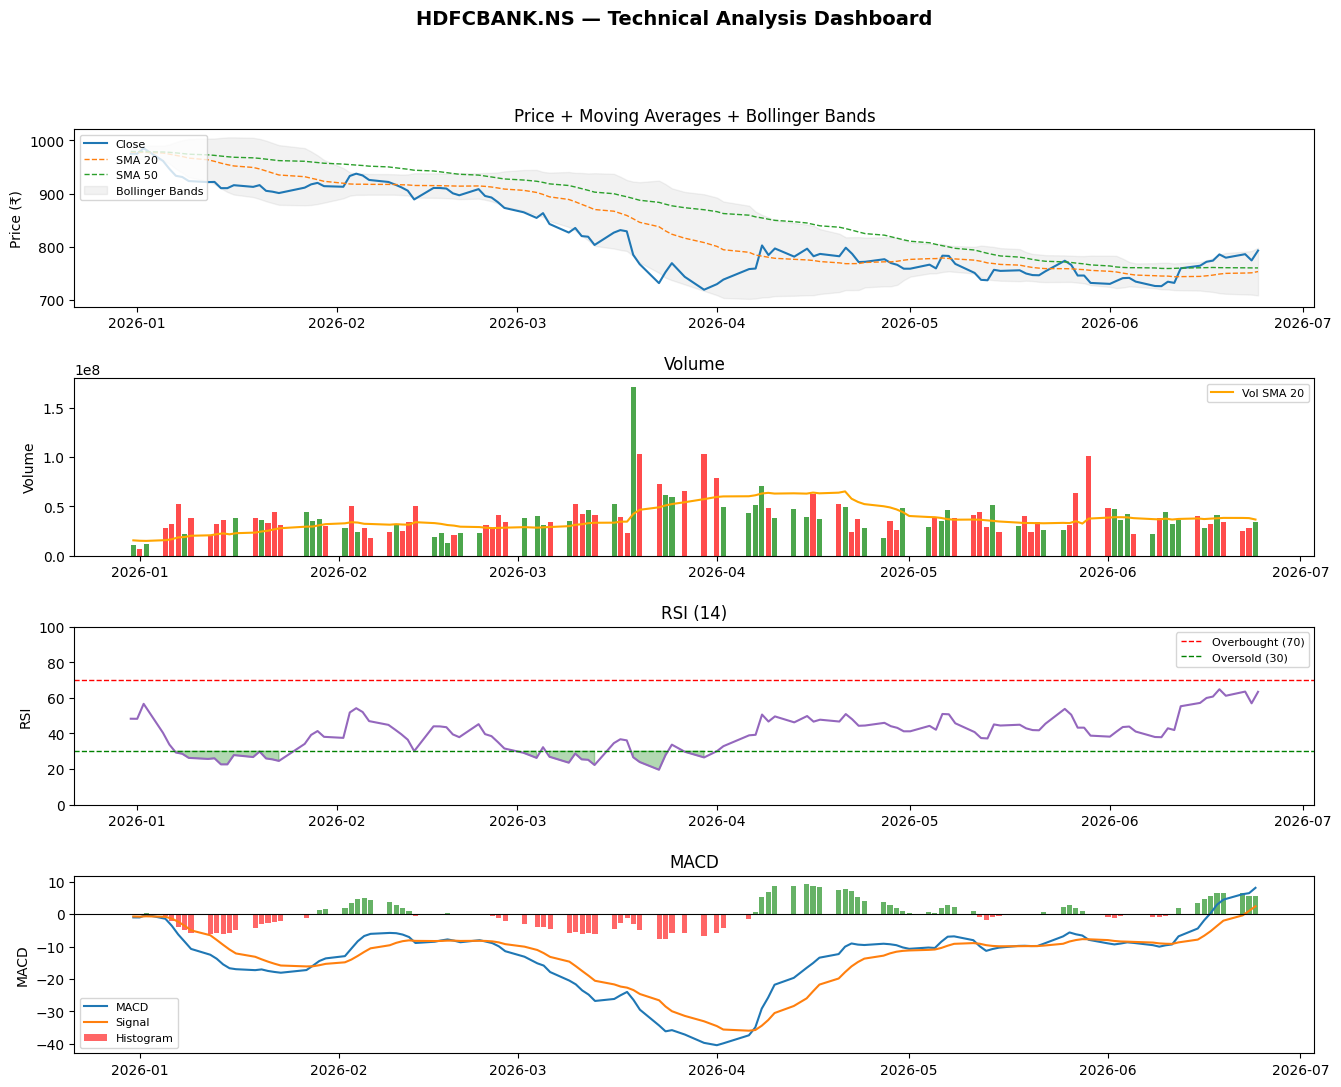

✅ Chart saved!


In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_stock_analysis(df, ticker="RELIANCE.NS"):
    """Full technical analysis chart for a stock"""

    stock = df[df["Ticker"] == ticker].copy().tail(120)  # last 6 months

    fig = plt.figure(figsize=(16, 12))
    fig.suptitle(f"{ticker} — Technical Analysis Dashboard", fontsize=14, fontweight="bold")
    gs = gridspec.GridSpec(4, 1, hspace=0.4)

    # ── Plot 1: Price + MAs + Bollinger Bands ──
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(stock["Date"], stock["Close"],    label="Close",    color="#1f77b4", lw=1.5)
    ax1.plot(stock["Date"], stock["SMA_20"],   label="SMA 20",   color="#ff7f0e", lw=1, ls="--")
    ax1.plot(stock["Date"], stock["SMA_50"],   label="SMA 50",   color="#2ca02c", lw=1, ls="--")
    ax1.fill_between(stock["Date"], stock["BB_Upper"], stock["BB_Lower"],
                     alpha=0.1, color="gray", label="Bollinger Bands")
    ax1.set_title("Price + Moving Averages + Bollinger Bands")
    ax1.set_ylabel("Price (₹)")
    ax1.legend(loc="upper left", fontsize=8)

    # ── Plot 2: Volume ──
    ax2 = fig.add_subplot(gs[1])
    colors = ["green" if c >= o else "red"
              for c, o in zip(stock["Close"], stock["Open"])]
    ax2.bar(stock["Date"], stock["Volume"], color=colors, alpha=0.7)
    ax2.plot(stock["Date"], stock["Volume_SMA_20"],
             color="orange", lw=1.5, label="Vol SMA 20")
    ax2.set_title("Volume")
    ax2.set_ylabel("Volume")
    ax2.legend(fontsize=8)

    # ── Plot 3: RSI ──
    ax3 = fig.add_subplot(gs[2])
    ax3.plot(stock["Date"], stock["RSI"], color="#9467bd", lw=1.5)
    ax3.axhline(70, color="red",   lw=1, ls="--", label="Overbought (70)")
    ax3.axhline(30, color="green", lw=1, ls="--", label="Oversold (30)")
    ax3.fill_between(stock["Date"], stock["RSI"], 70,
                     where=(stock["RSI"] >= 70), alpha=0.3, color="red")
    ax3.fill_between(stock["Date"], stock["RSI"], 30,
                     where=(stock["RSI"] <= 30), alpha=0.3, color="green")
    ax3.set_title("RSI (14)")
    ax3.set_ylabel("RSI")
    ax3.set_ylim(0, 100)
    ax3.legend(fontsize=8)

    # ── Plot 4: MACD ──
    ax4 = fig.add_subplot(gs[3])
    ax4.plot(stock["Date"], stock["MACD"],        label="MACD",   color="#1f77b4", lw=1.5)
    ax4.plot(stock["Date"], stock["MACD_Signal"], label="Signal", color="#ff7f0e", lw=1.5)
    colors_hist = ["green" if v >= 0 else "red" for v in stock["MACD_Hist"]]
    ax4.bar(stock["Date"], stock["MACD_Hist"], color=colors_hist, alpha=0.6, label="Histogram")
    ax4.axhline(0, color="black", lw=0.8)
    ax4.set_title("MACD")
    ax4.set_ylabel("MACD")
    ax4.legend(fontsize=8)

    plt.savefig(f"{BASE}/data/output/02_technical_{ticker.replace('.NS','')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Chart saved!")

# Plot for 3 different stocks
for stock in ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS"]:
    plot_stock_analysis(tech_df, ticker=stock)

In [6]:
def save_technical_data(df):
    # Save full enriched dataset
    df.to_parquet(f"{BASE}/data/processed/nifty50_technical.parquet", index=False)
    print("✅ Full technical data saved as Parquet")

    # Save latest day for Power BI
    latest = df.groupby("Ticker").last().reset_index()
    latest.to_csv(f"{BASE}/data/output/latest_signals.csv", index=False)
    print("✅ Latest signals saved as CSV for Power BI")

    # Save full data for Power BI
    df.to_csv(f"{BASE}/data/output/nifty50_technical_powerbi.csv", index=False)
    print("✅ Full technical data saved as CSV for Power BI")

    # Summary stats
    latest_signals = df.groupby("Ticker").last()
    signal_counts = latest_signals["Signal"].value_counts()
    print(f"\n📊 Current Market Signal Summary:")
    print(signal_counts.to_string())

save_technical_data(tech_df)

✅ Full technical data saved as Parquet
✅ Latest signals saved as CSV for Power BI
✅ Full technical data saved as CSV for Power BI

📊 Current Market Signal Summary:
Signal
Weak Sell      16
Weak Buy       13
Strong Buy      8
Strong Sell     6
Neutral         3
Buy             3


## ✅ Notebook 2 Complete!

**Save to GitHub:**
File → Save a copy in GitHub → `notebooks/02_technical_analysis.ipynb`
Commit message: `Add Notebook 2: Technical analysis with RSI, MACD, Bollinger Bands and trading signals`

**Next:** Notebook 3 — Fundamental Analysis (P/E ratio, P/B ratio, ROE, EPS growth)